In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("SuperStoreOrders.csv")

In [2]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


### Data Understanding

In [3]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [4]:
df.shape

(51290, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
### here orderdate, shipdate, sales are in object type it may skew our analysis..
df['order_date'] = pd.to_datetime(df['order_date'], format = "mixed")
df['ship_date'] = pd.to_datetime(df['ship_date'],format = "mixed")

In [7]:
df.info()# coverted object type into datetime...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  object        
 15  qu

In [8]:
df['profit'].dtype

dtype('float64')

### 1. On Continous variable

In [9]:
df.describe()

,order_date,ship_date,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-04-30 17:16:21.384285440,2013-05-05 19:10:10.504971520,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-02 00:00:00,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-06 00:00:00,2012-06-13 00:00:00,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-06-26 00:00:00,2013-06-30 00:00:00,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-04-30 00:00:00,2014-05-09 00:00:00,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-07-01 00:00:00,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,2.278766,0.212280,174.424113,57.296804,1.098931


In [10]:
#grouping dtypes..
continous = df.select_dtypes(include = "number").columns
discrete = df.select_dtypes(include = "object").columns

print(df[continous].columns)
print(df[discrete].columns)

Index(['quantity', 'discount', 'profit', 'shipping_cost', 'year'], dtype='object')
Index(['order_id', 'ship_mode', 'customer_name', 'segment', 'state', 'country',
       'market', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'order_priority'],
      dtype='object')


In [11]:
df['discount'].unique()

array([0.   , 0.1  , 0.5  , 0.4  , 0.45 , 0.55 , 0.47 , 0.002, 0.6  ,
       0.2  , 0.8  , 0.17 , 0.25 , 0.7  , 0.402, 0.35 , 0.27 , 0.15 ,
       0.37 , 0.65 , 0.3  , 0.07 , 0.602, 0.32 , 0.202, 0.57 , 0.85 ])

In [12]:
df['discount'].isna().sum()# checking for nan,na,empty hidden values..

0

In [13]:
df[df['discount'] == 0.850]  #extracting data with highest discount of 0.850 --

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
12082,IT-2012-2675422,2012-05-31,2012-02-06,Second Class,Benjamin Farhat,Home Office,Lower Saxony,Germany,EU,Central,...,Furniture,Tables,"Bevis Conference Table, Fully Assembled",555,4,0.85,-1924.542,62.75,High,2012
18023,IT-2012-5588535,2012-11-16,2012-11-21,Standard Class,Mitch Willingham,Corporate,Lower Saxony,Germany,EU,Central,...,Furniture,Tables,"Chromcraft Coffee Table, Fully Assembled",242,6,0.85,-1144.116,23.38,High,2012


In [14]:
df['discount'].describe()

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: discount, dtype: float64

In [15]:
df["quantity"].describe()

count    51290.000000
mean         3.476545
std          2.278766
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         14.000000
Name: quantity, dtype: float64

In [16]:
df['quantity'].value_counts()

quantity
2     12748
3      9682
1      8963
4      6385
5      4882
6      3020
7      2385
8      1361
9       987
10      276
14      186
12      176
11      156
13       83
Name: count, dtype: int64

    #Observation
    majority of the sales orders consist of [1-3 units] indicates retail-driven-customers,
    and Higher quantities [10-13 units] occur less frequently represents occasional bulk purchases By corporate or wholesale customers..

In [17]:
#percentage_of_order_1to3= (12748 + 9682 + 8963)/ len(df['quantity'])*100
#percentage_of_order_10to13=(276+156+176+83)/len(df['quantity'])*100
#df['quantity'].mean()

quantity_dist = df['quantity'].value_counts(normalize=True) * 100
percentage_1to3 = quantity_dist.loc[[1,2,3]].sum()
percentage_10to13= quantity_dist.loc[[10,11,12,13]].sum()
avg_order_size= quantity_dist.mean()
print("KPI")
print("1-3 units :", percentage_1to3)
print("10-13 units :", percentage_10to13)
print("Average order size :",avg_order_size)

KPI
1-3 units : 61.20686293624488
10-13 units : 1.3472411776174693
Average order size : 7.142857142857143


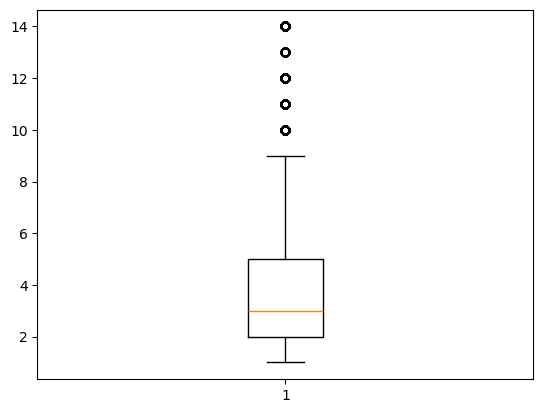

In [18]:
plt.boxplot(df['quantity'])
plt.show()

In [19]:
df['shipping_cost'].isna().sum()

0

In [20]:
print("KPI")

print("Average Shipping cost :",df['shipping_cost'].mean())
print("Maximum Shipping cost :",df['shipping_cost'].max())

KPI
Average Shipping cost : 26.375915188145832
Maximum Shipping cost : 933.57


In [21]:
df['profit'].describe()

count    51290.000000
mean        28.641740
std        174.424113
min      -6599.978000
25%          0.000000
50%          9.240000
75%         36.810000
max       8399.976000
Name: profit, dtype: float64

    # Observation
    -6599.978000 here data shows profit column may contain negative value ---> outliers!!!!
    Also profit column shows negative value may indicate losses on certain orders

In [22]:
df['year'].unique() 

array([2011, 2012, 2013, 2014], dtype=int64)

    # Observation
    we have total 4 years of sales data in this dataset...

In [23]:
df.isna().sum() # no missing values in this dataset

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

### On Discrete variable

In [24]:
df[discrete].head()

,order_id,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,order_priority
0,AG-2011-2040,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,Medium
1,IN-2011-47883,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,Medium
2,HU-2011-1220,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,High
3,IT-2011-3647632,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,High
4,IN-2011-47883,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,Medium


In [25]:
df['ship_mode'].unique() # Here ship_mode column is in standardized format no need for further formatting....

array(['Standard Class', 'Second Class', 'Same Day', 'First Class'],
      dtype=object)

In [26]:
df['ship_mode'].value_counts(normalize=True)*100 # no nan values.. found

ship_mode
Standard Class    60.001950
Second Class      20.099435
First Class       14.632482
Same Day           5.266134
Name: proportion, dtype: float64

    Observation 
    - Out of all shipping mode Standard Class is most popular with (60%) and preferred by customers.

In [27]:
df['segment'].unique()

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

In [28]:
df['segment'].value_counts(normalize= True)* 100

segment
Consumer       51.702086
Corporate      30.081887
Home Office    18.216027
Name: proportion, dtype: float64

    Observation
    Consumer has most of the purchase percentage, Then Corporate and lowest with Home office.
    Introducing discounts and providing offerce can increase purchase percentage in corporate and home office...

In [29]:
segment_proportion = df['segment'].value_counts(normalize = True) * 100
print("KPI")
print("percentage% of consumer :", segment_proportion.loc['Consumer'])
print("percentage% of corporate :", segment_proportion.loc['Corporate'])
print("percentage% of home office :", segment_proportion.loc['Home Office'])
#(26518/51290)*100 (51.70%) shows consumer 
#(15429/51290)*100 (30.08%)corporate people
#(9343/51290)*100 (18.21%) home office 

KPI
percentage% of consumer : 51.702086176642624
percentage% of corporate : 30.08188730746734
percentage% of home office : 18.21602651589004


In [30]:
df['market'].value_counts()

market
APAC      11002
LATAM     10294
EU        10000
US         9994
EMEA       5029
Africa     4587
Canada      384
Name: count, dtype: int64

In [31]:
print("KPI")
print("Percentage of each market")
df['market'].value_counts(normalize= True)*100

KPI
Percentage of each market


market
APAC      21.450575
LATAM     20.070189
EU        19.496978
US        19.485280
EMEA       9.805030
Africa     8.943264
Canada     0.748684
Name: proportion, dtype: float64

    Oberservation
    The APAC clearly dominating the market, followed closely by LATAM, EU AND US 
    with lowest in canada represents the potential growth opportunity.

In [32]:
print("Category by volumn:\n",df['category'].value_counts())
print()
print("Category by Percentage:\nKPI\n",df['category'].value_counts(normalize= True)*100)

Category by volumn:
 category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

Category by Percentage:
KPI
 category
Office Supplies    60.972899
Technology         19.771885
Furniture          19.255215
Name: proportion, dtype: float64


    Oberservations
    Out of all Office Supplies having more transaction volumn, Technology follows Next and lastly
    Furniture with low transaction. this indicates majority of orders are low cost..

In [33]:
df['sub_category'].value_counts()

sub_category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones         3357
Furnishings    3170
Accessories    3075
Labels         2606
Envelopes      2435
Supplies       2425
Fasteners      2420
Bookcases      2411
Copiers        2223
Appliances     1755
Machines       1486
Tables          861
Name: count, dtype: int64

In [34]:
print("Count",df['order_priority'].value_counts())
print("\nPercentage",df['order_priority'].value_counts(normalize=True)*100)

Count order_priority
Medium      29433
High        15501
Critical     3932
Low          2424
Name: count, dtype: int64

Percentage order_priority
Medium      57.385455
High        30.222266
Critical     7.666212
Low          4.726067
Name: proportion, dtype: float64


In [35]:
df.groupby('category')['sales'].describe()

,count,unique,top,freq
category,,,,
Furniture,9876,1597,50,55
Office Supplies,31273,1195,13,560
Technology,10141,1574,80,52


In [36]:
df.groupby('category')['profit'].sum()

category
Furniture          286782.25380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64

In [37]:
df['region'].value_counts()

region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

In [38]:
df.groupby('region')['profit'].sum()

region
Africa             88871.63100
Canada             17817.39000
Caribbean          34571.32104
Central           311403.98164
Central Asia      132480.18700
EMEA               43897.97100
East               91522.78000
North             194597.95252
North Asia        165578.42100
Oceania           121666.64200
South             140355.76618
Southeast Asia     17852.32900
West              108418.44890
Name: profit, dtype: float64

     #Observation
     The Central Region marks highest profit about 3,11,403/- Followed by North 1,94,597/- 
     lowest profit by Canada 17,817/- and Southest Asia 17,852 Need to Focus on this regions like introducing discounts, offers may increase profit...

In [39]:
#Does ship mode preference differ by region? 
df.groupby('region')['ship_mode'].describe()

,count,unique,top,freq
region,,,,
Africa,4587,4,Standard Class,2659
Canada,384,4,Standard Class,194
Caribbean,1690,4,Standard Class,1002
Central,11117,4,Standard Class,6780
Central Asia,2048,4,Standard Class,1277
EMEA,5029,4,Standard Class,3036
East,2848,4,Standard Class,1673
North,4785,4,Standard Class,2901
North Asia,2338,4,Standard Class,1377


    Observation
    Standard Class Dominate overall globe, Many regions prefer cheaper and slower shipping mode make 
    Canada has lowest share of standard class, suggesting greater acceptance of premium shipping options, 
    southeast asia has highest acceptance of standard class mode due to higher cost and limited availability of faster shipping modes

    KEY NOTE ==> Improving Standard class speed globally, while promoting premium shipping in markets 
    like canada and all over the globe too...
    

In [40]:
#Do corporate customers prefer specific shipping modes? 
df.groupby('segment')['ship_mode'].describe()

,count,unique,top,freq
segment,,,,
Consumer,26518,4,Standard Class,15876
Corporate,15429,4,Standard Class,9258
Home Office,9343,4,Standard Class,5641


    Observation
    Across all the shiping mode the standard class has more influence then any other mode.
    Every Segment prefers cheaper and slower shipping. 
    KPI ==> This indicates global cost-conscious Customer Base. Introducing targeted discounts or loyalty programs for premium shipping could encourage faster delivery adoption.

In [41]:
# Which region + segment combination brings the highest profit?
df.groupby('region')['profit'].agg(['count','mean'])

,count,mean
region,,
Africa,4587,19.374674
Canada,384,46.399453
Caribbean,1690,20.456403
Central,11117,28.011512
Central Asia,2048,64.687591
EMEA,5029,8.728966
East,2848,32.135808
North,4785,40.668329
North Asia,2338,70.820539


    Observation
    Highest Profitable Regions ---> The North asia Region has highest mean profit i.e 70.8 followed by South Asia with 64.68
    Lowest Profitable Regions ---> The Southest Asia and EmEa has lowest mean of 5 and 8 
    
    KPI ==> Even though Central has the highest single profit, Central Asia is more profitable
    overall because its average profit per order (mean) is higher.
    but Central Asia/North Asia are more profitable overall due to higher averages.

In [42]:
df.groupby('segment')['profit'].describe()

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Consumer,26518.0,28.254008,174.006045,-6599.978,0.0,9.1800,36.6525,6719.9808
Corporate,15429.0,28.698286,177.428209,-4088.376,0.0,9.3184,36.9600,8399.9760
Home Office,9343.0,29.648847,170.577590,-3399.980,0.0,9.3200,37.0800,3919.9888


In [43]:
df.groupby('segment')['profit'].agg(['count','mean'])

,count,mean
segment,,
Consumer,26518,28.254008
Corporate,15429,28.698286
Home Office,9343,29.648847


    Observation
    Highest profitable segment is Home Office with slightly higher (mean = 29.6) followed by corporate and consumer...
    The Three segments has losses with min of -6599 highest by consumers and -4088 and         -3399 by corporate and home office 
    
    KPI ==> OVERALL all segments did well with slight difference but having most losse need to figure out the reasons behind them...

In [44]:
df.groupby('category')['region'].describe()

,count,unique,top,freq
category,,,,
Furniture,9876,13,Central,2046
Office Supplies,31273,13,Central,6936
Technology,10141,13,Central,2135


In [45]:
df.groupby('category')['region'].min()

category
Furniture          Africa
Office Supplies    Africa
Technology         Africa
Name: region, dtype: object

In [46]:
df.groupby('category')['region'].max()

category
Furniture          West
Office Supplies    West
Technology         West
Name: region, dtype: object

In [47]:
pd.crosstab(df['region'],df['category'])

category,Furniture,Office Supplies,Technology
region,,,
Africa,631,3045,911
Canada,42,277,65
Caribbean,376,973,341
Central,2046,6936,2135
Central Asia,478,1111,459
EMEA,770,3297,962
East,601,1712,535
North,945,2914,926
North Asia,522,1332,484


    Observation
    Outof all regions Central dominates in every category. office supplies have more orders with 31273
    Africa has lowest order in all three category
    West has highest order in all category.
    
    KPI ==> Central and West Regions can be consider as key contributers towards revenue
            But Africa may need marketing and distribution stretagies to boost the engagement


In [48]:
df.groupby('sub_category')['region'].describe()

,count,unique,top,freq
sub_category,,,,
Accessories,3075,13,Central,671
Appliances,1755,13,Central,408
Art,4883,13,Central,1189
Binders,6152,13,Central,1418
Bookcases,2411,13,Central,515
Chairs,3434,13,Central,704
Copiers,2223,13,Central,443
Envelopes,2435,13,Central,489
Fasteners,2420,13,Central,488


In [49]:
df.groupby('order_priority')['ship_mode'].describe()

,count,unique,top,freq
order_priority,,,,
Critical,3932,3,First Class,1734
High,15501,4,Standard Class,6809
Low,2424,1,Standard Class,2424
Medium,29433,4,Standard Class,21542


In [50]:
pd.crosstab(df['order_priority'],df['ship_mode'])

ship_mode,First Class,Same Day,Second Class,Standard Class
order_priority,,,,
Critical,1734,742,1456,0
High,3413,1269,4010,6809
Low,0,0,0,2424
Medium,2358,690,4843,21542


    #Observation
    The order_priority which is critical should be first priority that is First Class 1734 more orders with second highest is second class
    it should be same day atleast -- need to improve and
    high priority has more second class ship mode
    medium has more standard class which is fair..
    
    KPI ==> percentage of high-priority orders delivered using fast shipping modes, identify delivery delays.. by order_date vs ship_date...

In [51]:
df['shipping_days']= df['ship_date']- df['order_date']

In [52]:
df['shipping_days'].head()

0   151 days
1   212 days
2   120 days
3   120 days
4   212 days
Name: shipping_days, dtype: timedelta64[ns]

In [53]:
df['shipping_days'].describe()

count                         51290
mean      5 days 01:53:49.120686293
std      97 days 18:30:57.003928097
min             -322 days +00:00:00
25%                 1 days 00:00:00
50%                 4 days 00:00:00
75%                59 days 00:00:00
max               214 days 00:00:00
Name: shipping_days, dtype: object

KPI ==> The Average Delivery time is 5 days 

In [54]:
late_deliveries = df[df['shipping_days']> '7days']
late_deliveries

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011,151 days
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011,212 days
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011,120 days
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011,120 days
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011,212 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014,91 days
51286,MO-2014-2560,2014-12-31,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014,121 days
51287,MX-2014-110527,2014-12-31,2015-02-01,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014,32 days
51288,MX-2014-114783,2014-12-31,2015-06-01,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014,152 days


In [55]:
print(f"Percentage(%) of Late Deliveries = {(len(late_deliveries)/51290)*100:.2f}%")

Percentage(%) of Late Deliveries = 28.58%


In [56]:
incorrect_entries = df[df['ship_date']<df['order_date']]
incorrect_entries

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days
52,ID-2011-41632,2011-06-01,2011-01-13,Standard Class,Robert Dilbeck,Home Office,Ho Chí Minh City,Vietnam,APAC,Southeast Asia,...,Storage,"Tenex Trays, Blue",90,2,0.17,29.2686,3.62,Medium,2011,-139 days
54,ID-2011-41632,2011-06-01,2011-01-13,Standard Class,Robert Dilbeck,Home Office,Ho Chí Minh City,Vietnam,APAC,Southeast Asia,...,Paper,"Enermax Memo Slips, Recycled",39,3,0.17,11.5893,2.45,Medium,2011,-139 days
57,CA-2011-141817,2011-06-01,2011-01-13,Standard Class,Mick Brown,Consumer,Pennsylvania,United States,US,East,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,20,3,0.20,4.8840,1.85,Low,2011,-139 days
83,AO-2011-1670,2011-08-01,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,...,Bookcases,"Ikea Classic Bookcase, Pine","2,479",6,0.00,49.5000,349.87,High,2011,-200 days
85,IT-2011-4546695,2011-08-01,2011-01-14,Standard Class,Darren Powers,Consumer,Midi-Pyrénées,France,EU,Central,...,Bookcases,"Ikea Classic Bookcase, Metal",987,6,0.60,-1011.6360,65.64,Medium,2011,-199 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49132,US-2014-117282,2014-11-30,2014-05-12,Second Class,Rick Hansen,Consumer,Ouest,Haiti,LATAM,Caribbean,...,Labels,"Novimex Legal Exhibit Labels, Alphabetical",21,5,0.40,-8.9200,1.86,High,2014,-202 days
49133,IN-2014-46420,2014-11-30,2014-05-12,Standard Class,Naresj Patel,Consumer,Anhui,China,APAC,North Asia,...,Fasteners,"Advantus Thumb Tacks, Metal",27,2,0.00,3.5400,1.35,Medium,2014,-202 days
49134,ZI-2014-6740,2014-11-30,2014-05-12,Standard Class,Beth Thompson,Home Office,Bulawayo,Zimbabwe,Africa,Africa,...,Storage,"Rogers Box, Blue",7,1,0.70,-16.3290,0.67,High,2014,-202 days
49135,ZI-2014-6740,2014-11-30,2014-05-12,Standard Class,Beth Thompson,Home Office,Bulawayo,Zimbabwe,Africa,Africa,...,Art,"Sanford Pens, Fluorescent",4,1,0.70,-5.2020,0.50,High,2014,-202 days


In [57]:
print(f"Percentage of Incorrect Entries = {(9687/51290) * 100:.2f}%")

Percentage of Incorrect Entries = 18.89%


In [58]:
df.groupby('order_priority')['discount'].describe()

,count,mean,std,min,25%,50%,75%,max
order_priority,,,,,,,,
Critical,3932.0,0.136516,0.208413,0.0,0.0,0.0,0.2,0.80
High,15501.0,0.143341,0.213095,0.0,0.0,0.0,0.2,0.85
Low,2424.0,0.142200,0.210739,0.0,0.0,0.0,0.2,0.80
Medium,29433.0,0.143592,0.212485,0.0,0.0,0.0,0.2,0.80


KPI -- The order_priority medium has high discounts followed by High, Critical and low

In [59]:
df.groupby('order_priority')['segment'].describe()

,count,unique,top,freq
order_priority,,,,
Critical,3932,3,Consumer,2071
High,15501,3,Consumer,8257
Low,2424,3,Consumer,1173
Medium,29433,3,Consumer,15017


In [60]:
pd.crosstab(df['order_priority'],df['segment'])

segment,Consumer,Corporate,Home Office
order_priority,,,
Critical,2071,1185,676
High,8257,4431,2813
Low,1173,744,507
Medium,15017,9069,5347


    #Observation
    The consumers, corporate and home office prefers MEDIUM order_priority.
    after HIGH priority leads and CRITICAL is low and LOW is lowest priority.
    
    KPI==> Need to increase more INVENTORIES to supply manage the order_priority

In [61]:
#   df['discount'].corr(df['sales']) #ValueError: could not convert string to float: '1,648'
#   df['sales'] = df['sales'].astype(float)
# df.dtypes # sales                      object

# valueerror could not convert string to float '1,648'
# replacing 1,648 ( , ) with ('')
df['sales'] = df['sales'].replace(',', '', regex=True)
df['sales'] = df['sales'].astype(float)

In [62]:
df['sales'].dtype 

dtype('float64')

In [63]:
df[['sales','profit','quantity']].describe()

,sales,profit,quantity
count,51290.000000,51290.000000,51290.000000
mean,246.498440,28.641740,3.476545
std,487.567175,174.424113,2.278766
min,0.000000,-6599.978000,1.000000
25%,31.000000,0.000000,2.000000
50%,85.000000,9.240000,3.000000
75%,251.000000,36.810000,5.000000
max,22638.000000,8399.976000,14.000000


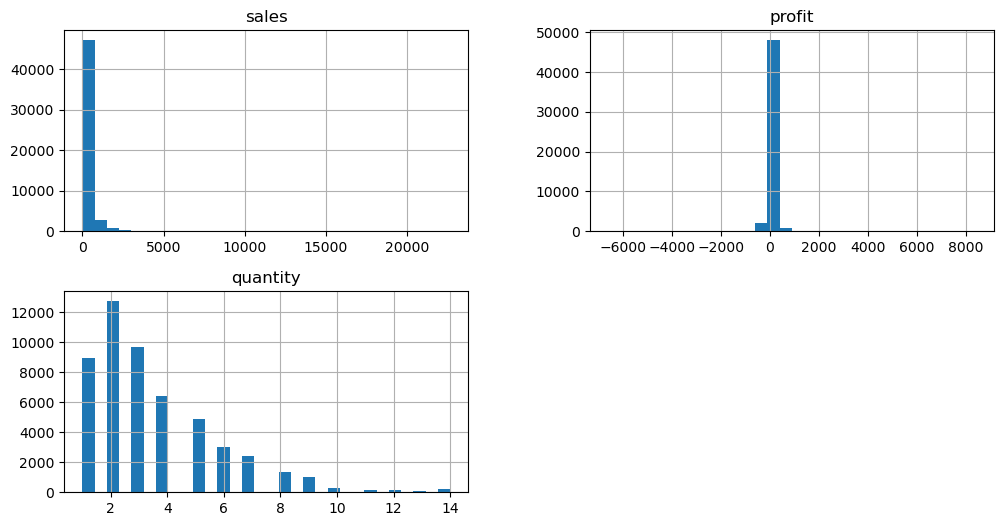

In [64]:
df[['sales','profit','quantity']].hist(bins=30,figsize=(12,6))
plt.show()

In [65]:
print("----Before Transformation----")
print("skewness = ",df['sales'].skew())# here the the result shows the sales data is right skewed 
# further investigation 
# option for right skewed data val(8.13798050972221) > 0 == right skewed.. we can use log, boxcox and root
print("\n----After Transformation----")
df['log_sales'] = np.log1p(df['sales'])
print("skewness = ",df['log_sales'].skew())

----Before Transformation----
skewness =  8.13798050972221

----After Transformation----
skewness =  0.14669876135837712


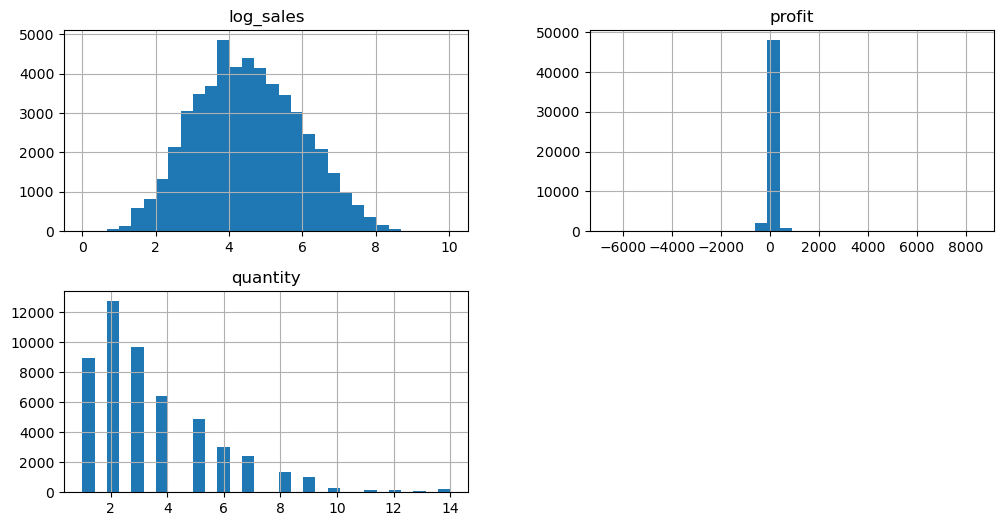

In [66]:
df[['log_sales','profit','quantity']].hist(bins=30,figsize=(12,6))
plt.show()

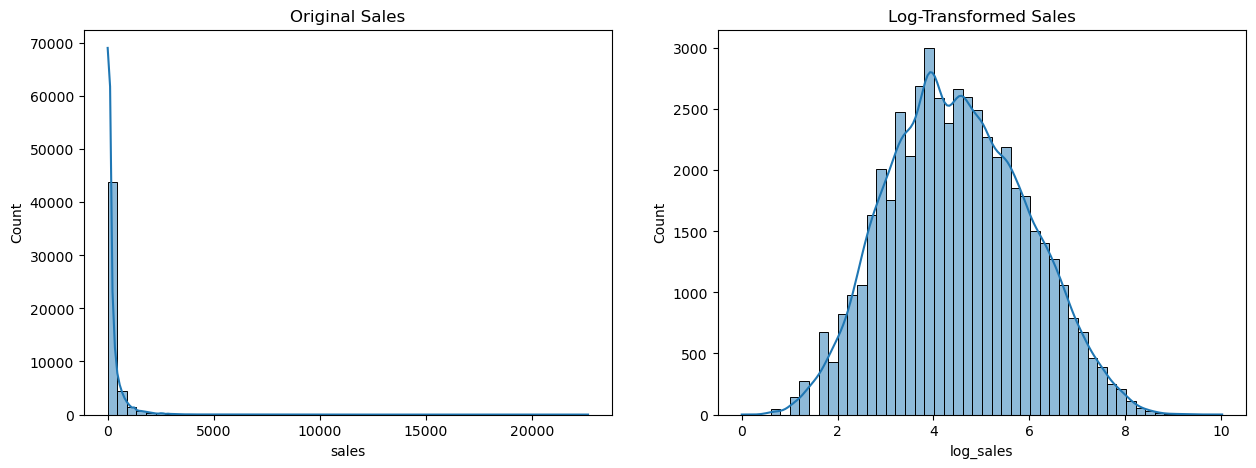

In [67]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.histplot(df['sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Original Sales')
sns.histplot(df['log_sales'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Sales')
plt.show()

sns.histplot(df['sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Original Sales')
sns.histplot(df['log_sales'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Sales')
plt.show()


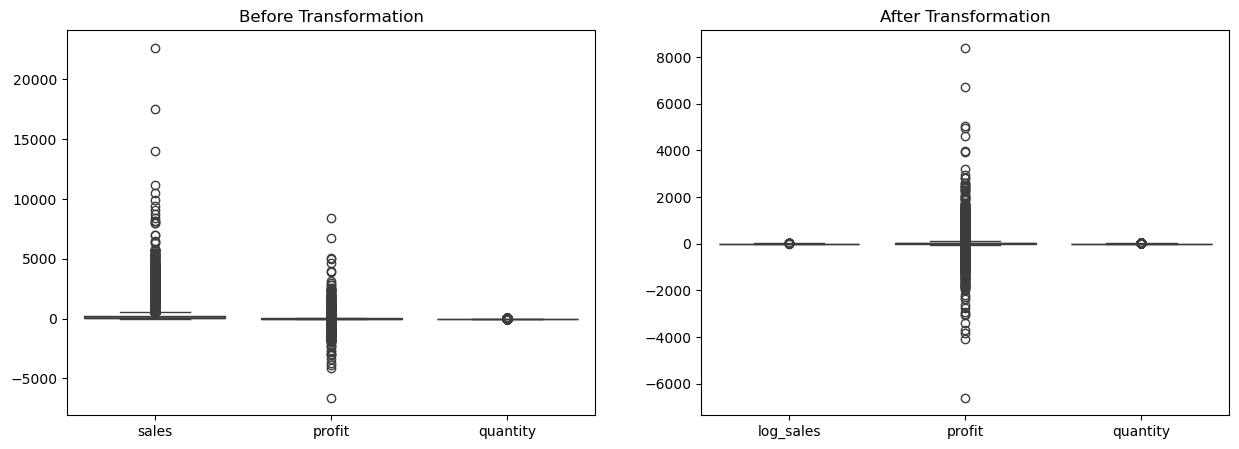

In [68]:
fig,axes = plt.subplots(1,2,figsize=(15,5))
sns.boxplot(data = df[['sales','profit','quantity']],ax = axes[0])
axes[0].set_title("Before Transformation")
sns.boxplot(data = df[['log_sales','profit','quantity']],ax = axes[1])
axes[1].set_title("After Transformation")
plt.show()

In [69]:
#df['quantity'].isna().sum() --> 0
#(df['quantity']<0).sum() ---> 0
#df['quantity'].skew()#1.3603677307024198#Quantity skewness is only ~1.36, it’s not extreme like Sales (8+). 
#For business dashboards, you can keep it raw. For modeling, a mild transformation (sqrt or log) can help.

In [70]:
df['discount'].corr(df['sales'])

-0.0867280171632076

    Observation
    The Correlation shows there is negative correlation between discount and sales 
    it should be positively correlated, if discount increases sales has to be increase 
    BUT its not happening need further analysis...

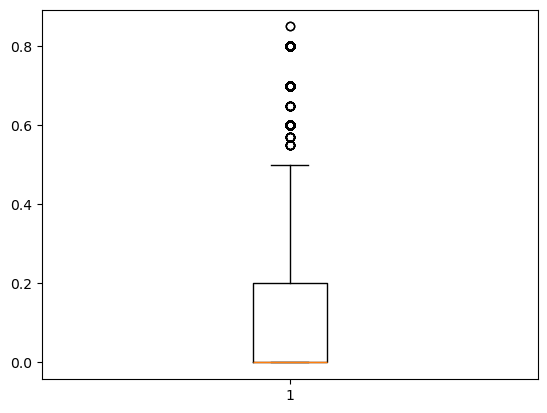

In [71]:
plt.boxplot(df['discount'])
plt.show()

In [72]:
df['discount'].skew()

1.3877745521338385

In [73]:
df['discount_level'] = pd.cut(df['discount'], bins = [-0.01, 0 , 0.2, 0.4, 0.6, 1],
                              labels= ['No Discount','Low (0-20%)','Medium (20-40%)','High (40-60%)','Extreme (60-100%)']) 

In [74]:
df['discount_level'].value_counts()

discount_level
No Discount          29009
Low (0-20%)          10953
High (40-60%)         4817
Medium (20-40%)       4367
Extreme (60-100%)     2144
Name: count, dtype: int64

In [75]:
df.groupby('discount_level',observed = True)['profit'].mean()

discount_level
No Discount           61.039514
Low (0-20%)           46.838458
Medium (20-40%)      -42.883229
High (40-60%)        -80.599600
Extreme (60-100%)   -111.549790
Name: profit, dtype: float64

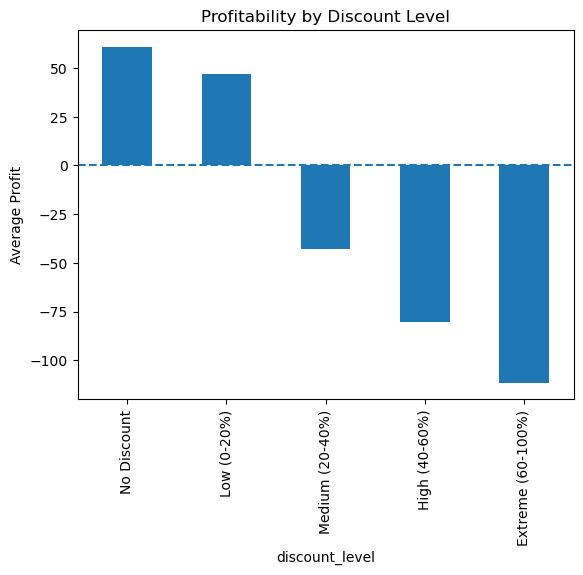

In [76]:
df.groupby('discount_level',observed = True)['profit'].mean().plot(kind = 'bar')
plt.axhline(0,linestyle='--')
plt.ylabel("Average Profit")
plt.title("Profitability by Discount Level")
plt.show()

    - #ObservationDiscounts up to 20% are sustainable, but beyond that, average profit turns negative, indicating business loss.

In [77]:
df['discount'].corr(df['profit'])

-0.3163749562483986

# Data Cleaning


In [78]:
#checking for wrong datatypes
df.info() # all dtypes are in correct format...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   order_id        51290 non-null  object         
 1   order_date      51290 non-null  datetime64[ns] 
 2   ship_date       51290 non-null  datetime64[ns] 
 3   ship_mode       51290 non-null  object         
 4   customer_name   51290 non-null  object         
 5   segment         51290 non-null  object         
 6   state           51290 non-null  object         
 7   country         51290 non-null  object         
 8   market          51290 non-null  object         
 9   region          51290 non-null  object         
 10  product_id      51290 non-null  object         
 11  category        51290 non-null  object         
 12  sub_category    51290 non-null  object         
 13  product_name    51290 non-null  object         
 14  sales           51290 non-null  float6

In [79]:
# checking for wrong data 
df['sales']

0        408.0
1        120.0
2         66.0
3         45.0
4        114.0
         ...  
51285     14.0
51286      4.0
51287     26.0
51288      7.0
51289      3.0
Name: sales, Length: 51290, dtype: float64

In [80]:
#Negative Shipping_days in dataframe
incorrect_entries

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days
52,ID-2011-41632,2011-06-01,2011-01-13,Standard Class,Robert Dilbeck,Home Office,Ho Chí Minh City,Vietnam,APAC,Southeast Asia,...,Storage,"Tenex Trays, Blue",90,2,0.17,29.2686,3.62,Medium,2011,-139 days
54,ID-2011-41632,2011-06-01,2011-01-13,Standard Class,Robert Dilbeck,Home Office,Ho Chí Minh City,Vietnam,APAC,Southeast Asia,...,Paper,"Enermax Memo Slips, Recycled",39,3,0.17,11.5893,2.45,Medium,2011,-139 days
57,CA-2011-141817,2011-06-01,2011-01-13,Standard Class,Mick Brown,Consumer,Pennsylvania,United States,US,East,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,20,3,0.20,4.8840,1.85,Low,2011,-139 days
83,AO-2011-1670,2011-08-01,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,...,Bookcases,"Ikea Classic Bookcase, Pine","2,479",6,0.00,49.5000,349.87,High,2011,-200 days
85,IT-2011-4546695,2011-08-01,2011-01-14,Standard Class,Darren Powers,Consumer,Midi-Pyrénées,France,EU,Central,...,Bookcases,"Ikea Classic Bookcase, Metal",987,6,0.60,-1011.6360,65.64,Medium,2011,-199 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49132,US-2014-117282,2014-11-30,2014-05-12,Second Class,Rick Hansen,Consumer,Ouest,Haiti,LATAM,Caribbean,...,Labels,"Novimex Legal Exhibit Labels, Alphabetical",21,5,0.40,-8.9200,1.86,High,2014,-202 days
49133,IN-2014-46420,2014-11-30,2014-05-12,Standard Class,Naresj Patel,Consumer,Anhui,China,APAC,North Asia,...,Fasteners,"Advantus Thumb Tacks, Metal",27,2,0.00,3.5400,1.35,Medium,2014,-202 days
49134,ZI-2014-6740,2014-11-30,2014-05-12,Standard Class,Beth Thompson,Home Office,Bulawayo,Zimbabwe,Africa,Africa,...,Storage,"Rogers Box, Blue",7,1,0.70,-16.3290,0.67,High,2014,-202 days
49135,ZI-2014-6740,2014-11-30,2014-05-12,Standard Class,Beth Thompson,Home Office,Bulawayo,Zimbabwe,Africa,Africa,...,Art,"Sanford Pens, Fluorescent",4,1,0.70,-5.2020,0.50,High,2014,-202 days


In [81]:
#way 1 
#mask =df['order_date'] > df['ship_date']
#mask.value_counts()
#df.loc[mask, ['order_date','ship_date']] = df.loc[mask,['ship_date','order_date']].values

#way 2
df['order_date_corrected'] = np.where(df['order_date'] > df['ship_date'],      # check for and return true and false
                                                        df['ship_date'],      # returned if condition is true
                                                        df['order_date'])       # returned if condition is false

df['ship_date_corrected'] = np.where(df['order_date'] > df['ship_date'],
                                                        df['order_date'],
                                                        df['ship_date'])

In [82]:
df['ship_date_corrected'].head()

0   2011-06-01
1   2011-08-01
2   2011-05-01
3   2011-05-01
4   2011-08-01
Name: ship_date_corrected, dtype: datetime64[ns]

In [83]:
print(df['order_date_corrected'].describe(), end=("\n\n"))
print(df['ship_date_corrected'].describe()) # no negative values

count                            51290
mean     2013-04-02 13:10:18.085396992
min                2011-01-01 00:00:00
25%                2012-04-30 00:00:00
50%                2013-05-16 00:00:00
75%                2014-03-24 00:00:00
max                2014-12-31 00:00:00
Name: order_date_corrected, dtype: object

count                            51290
mean     2013-06-02 23:16:13.803860480
min                2011-01-03 00:00:00
25%                2012-07-19 00:00:00
50%                2013-08-11 00:00:00
75%                2014-06-23 00:00:00
max                2015-07-01 00:00:00
Name: ship_date_corrected, dtype: object


In [84]:
print("After correcting date correlaion is :",df['ship_date_corrected'].corr(df['order_date_corrected']))

After correcting date correlaion is : 0.9830266225352989


In [85]:
df['shipping_days_corrected'] = (df['ship_date_corrected'] - df['order_date_corrected']).dt.days
(df['shipping_days_corrected'] < 0).sum()
#checking for negative values if any... 

0

    KPI ==> Identified negative shipping days (≈18.9% incorrect entries). Corrected them by swapping order and ship dates where order_date > ship_date, ensuring no negative delivery durations remain.

In [86]:
print(df['shipping_days_corrected'].mean())
print(df['shipping_days_corrected'].max())
# DATA shows average delivery time is 61 days which is almost 2 months -- leads to potential outliers
# MAXIMUM days to deliver a product is 322 almost 11months --- Huge outlier
# need to Treat OUTLIERS....

61.42078377851433
322


In [87]:
df[df['shipping_days_corrected']>15]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,profit,shipping_cost,order_priority,year,shipping_days,log_sales,discount_level,order_date_corrected,ship_date_corrected,shipping_days_corrected
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,106.1400,35.46,Medium,2011,151 days,6.013715,No Discount,2011-01-01,2011-06-01,151
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,36.0360,9.72,Medium,2011,212 days,4.795791,Low (0-20%),2011-01-01,2011-08-01,212
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,29.6400,8.17,High,2011,120 days,4.204693,No Discount,2011-01-01,2011-05-01,120
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,-26.0550,4.82,High,2011,120 days,3.828641,High (40-60%),2011-01-01,2011-05-01,120
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,37.7700,4.70,Medium,2011,212 days,4.744932,Low (0-20%),2011-01-01,2011-08-01,212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,4.5188,0.89,Medium,2014,91 days,2.708050,Low (0-20%),2014-12-31,2015-04-01,91
51286,MO-2014-2560,2014-12-31,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,0.4200,0.49,Medium,2014,121 days,1.609438,No Discount,2014-12-31,2015-05-01,121
51287,MX-2014-110527,2014-12-31,2015-02-01,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,12.3600,0.35,Medium,2014,32 days,3.295837,No Discount,2014-12-31,2015-02-01,32
51288,MX-2014-114783,2014-12-31,2015-06-01,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,0.5600,0.20,Medium,2014,152 days,2.079442,No Discount,2014-12-31,2015-06-01,152


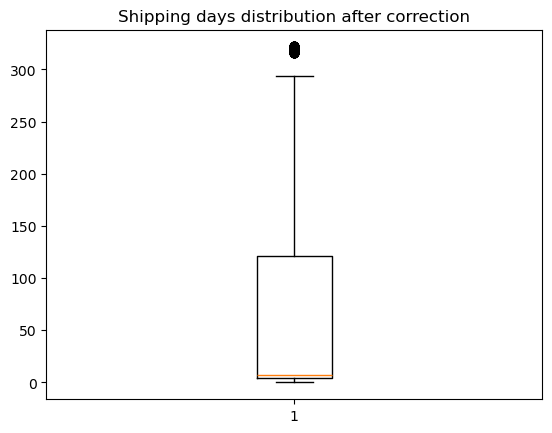

In [88]:
plt.boxplot(df['shipping_days_corrected'])
plt.title("Shipping days distribution after correction")
plt.show()

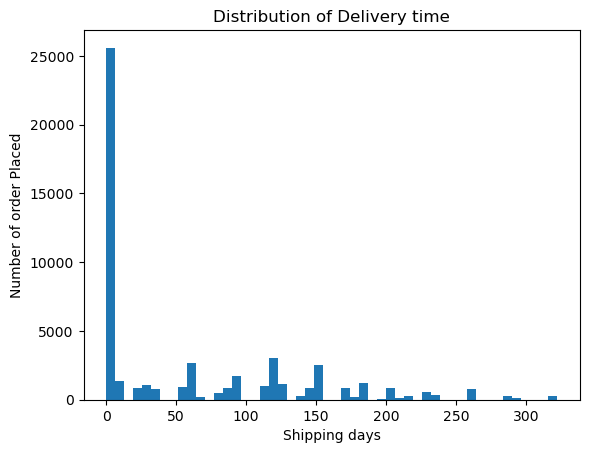

In [89]:
plt.hist(df['shipping_days_corrected'],bins = 50)
plt.title("Distribution of Delivery time")
plt.xlabel("Shipping days")
plt.ylabel("Number of order Placed")
plt.show()


In [90]:
print("Average Delivary Time :",df['shipping_days_corrected'].median())

Average Delivary Time : 7.0


In [91]:
df['profit_margin']= (df['profit']/df['sales'])*100
print("KPI \nProfit Margin\n\n",df['profit_margin'])

KPI 
Profit Margin

 0        26.014706
1        30.030000
2        44.909091
3       -57.900000
4        33.131579
           ...    
51285    32.277143
51286    10.500000
51287    47.538462
51288     8.000000
51289   -20.160000
Name: profit_margin, Length: 51290, dtype: float64


In [92]:
print("KPI")
Total_sales= df['sales'].sum()
print("Total Sales (Revenue) =",Total_sales)
Total_profit = df['profit'].sum()
print("Total Profit =",Total_profit)

KPI
Total Sales (Revenue) = 12642905.0
Total Profit = 1469034.8212799998


In [93]:
df['year']

0        2011
1        2011
2        2011
3        2011
4        2011
         ... 
51285    2014
51286    2014
51287    2014
51288    2014
51289    2014
Name: year, Length: 51290, dtype: int64

In [94]:
print("KPI\n")
print("---Yearly Sales---")
print(df.groupby('year')['sales'].sum().reset_index())

KPI

---Yearly Sales---
   year      sales
0  2011  2259511.0
1  2012  2677493.0
2  2013  3405860.0
3  2014  4300041.0


In [95]:
print("Average Yearly sales")
df.groupby('year')['sales'].mean()

Average Yearly sales


year
2011    251.112581
2012    244.252235
2013    246.819335
2014    245.282129
Name: sales, dtype: float64

In [96]:
#df.groupby('customer_name')['order_id'].count() will give duplicate count too... so use 
print("Number of orders placed by each customers..")
number_of_unique_orders = df.groupby('customer_name')['order_id'].nunique()
print(number_of_unique_orders)

Number of orders placed by each customers..
customer_name
Aaron Bergman         37
Aaron Hawkins         34
Aaron Smayling        31
Adam Bellavance       41
Adam Hart             42
                      ..
Xylona Preis          30
Yana Sorensen         32
Yoseph Carroll        31
Zuschuss Carroll      38
Zuschuss Donatelli    29
Name: order_id, Length: 795, dtype: int64


In [97]:
top_products = df.groupby('product_name')['sales'].sum().reset_index().sort_values(by='sales',ascending= False).head()
print("------------------TOP 5 PRODUCTS BY SALES------------------")
print(top_products)

------------------TOP 5 PRODUCTS BY SALES------------------
                               product_name    sales
310            Apple Smart Phone, Full Size  86936.0
970            Cisco Smart Phone, Full Size  76441.0
2415        Motorola Smart Phone, Full Size  73159.0
2501           Nokia Smart Phone, Full Size  71904.0
866   Canon imageCLASS 2200 Advanced Copier  61600.0


In [98]:
print("KPI")
print(df['year'].value_counts(normalize = True)*100)

KPI
year
2014    34.180152
2013    26.903880
2012    21.372587
2011    17.543381
Name: proportion, dtype: float64


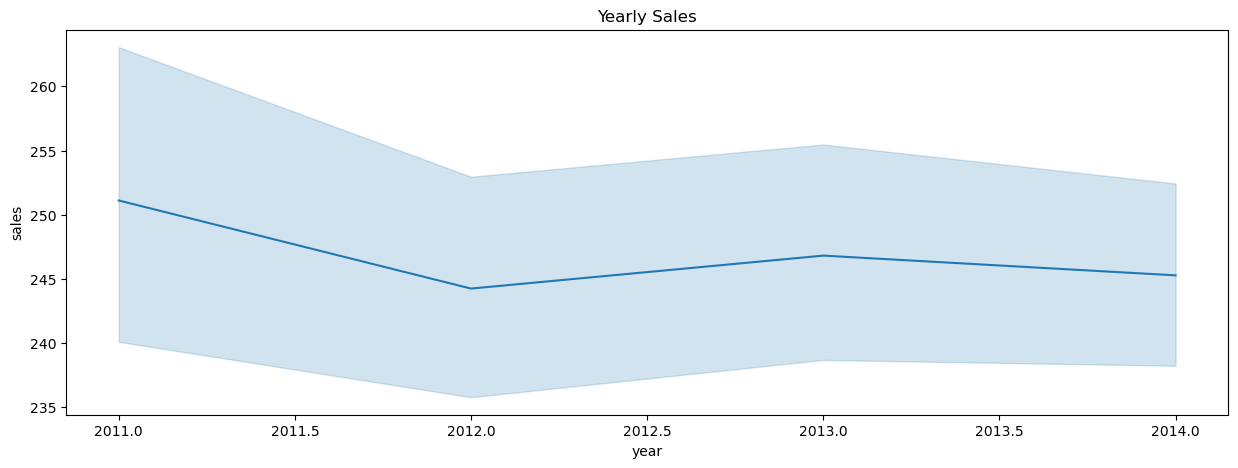

In [99]:
plt.figure(figsize=(15,5))
sns.lineplot(x=df['year'],y=df['sales'])
plt.title("Yearly Sales")
plt.show()

In [100]:
df.groupby('year')['sales'].agg(['count','mean','sum'])

,count,mean,sum
year,,,
2011,8998,251.112581,2259511.0
2012,10962,244.252235,2677493.0
2013,13799,246.819335,3405860.0
2014,17531,245.282129,4300041.0


    -#Observation 
    In Line plot year 2011 has more sales then rest and line is going down..
    The average yearly sales shows even 2011 mean is large but the count is more leading more sale out of all years...

    KPI-->
    2014 shows best sales till now i.e 43,00,041/-

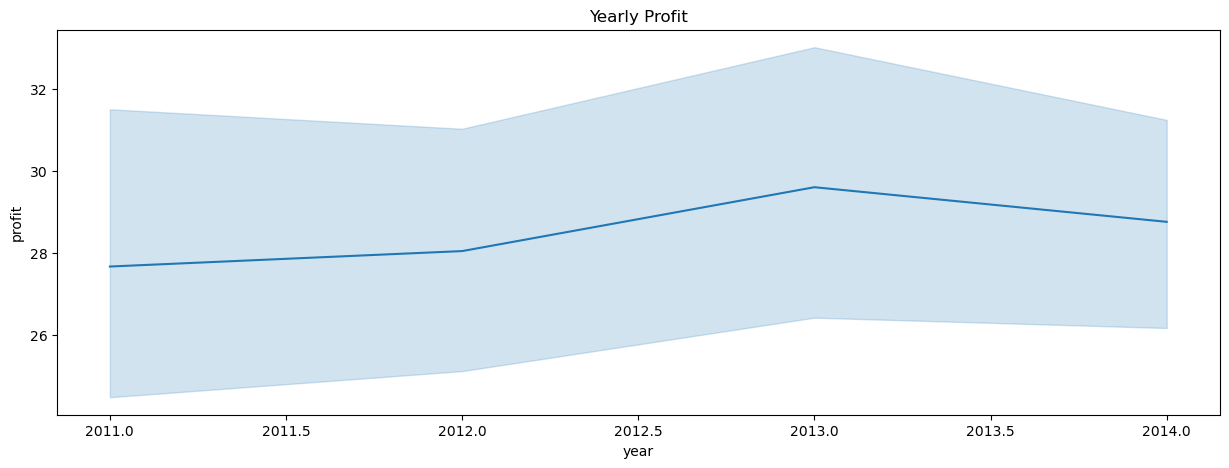

In [101]:
plt.figure(figsize=(15,5))
sns.lineplot(x=df['year'],y=df['profit'])
plt.title("Yearly Profit")
plt.show()

In [102]:
df.groupby('year')['profit'].agg(['count','mean','sum'])

,count,mean,sum
year,,,
2011,8998,27.666238,248940.81154
2012,10962,28.043722,307415.27910
2013,13799,29.604519,408512.76018
2014,17531,28.758540,504165.97046


In [107]:
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,shipping_cost,order_priority,year,shipping_days,log_sales,discount_level,order_date_corrected,ship_date_corrected,shipping_days_corrected,profit_margin
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,35.46,Medium,2011,151 days,6.013715,No Discount,2011-01-01,2011-06-01,151,26.014706
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,9.72,Medium,2011,212 days,4.795791,Low (0-20%),2011-01-01,2011-08-01,212,30.030000
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,8.17,High,2011,120 days,4.204693,No Discount,2011-01-01,2011-05-01,120,44.909091
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,4.82,High,2011,120 days,3.828641,High (40-60%),2011-01-01,2011-05-01,120,-57.900000
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,4.70,Medium,2011,212 days,4.744932,Low (0-20%),2011-01-01,2011-08-01,212,33.131579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,0.89,Medium,2014,91 days,2.708050,Low (0-20%),2014-12-31,2015-04-01,91,32.277143
51286,MO-2014-2560,2014-12-31,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,0.49,Medium,2014,121 days,1.609438,No Discount,2014-12-31,2015-05-01,121,10.500000
51287,MX-2014-110527,2014-12-31,2015-02-01,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,0.35,Medium,2014,32 days,3.295837,No Discount,2014-12-31,2015-02-01,32,47.538462
51288,MX-2014-114783,2014-12-31,2015-06-01,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,0.20,Medium,2014,152 days,2.079442,No Discount,2014-12-31,2015-06-01,152,8.000000


In [106]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year',
       'shipping_days', 'log_sales', 'discount_level', 'order_date_corrected',
       'ship_date_corrected', 'shipping_days_corrected', 'profit_margin'],
      dtype='object')

In [108]:
df.to_csv('Analysed_super_sales.csv')

In [110]:
df['year'].value_counts()

year
2014    17531
2013    13799
2012    10962
2011     8998
Name: count, dtype: int64